In [17]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

data_ct = pd.read_csv("data/customer_support_tickets.csv")
data_ct.shape

(8469, 17)

In [18]:
data_ct[["Ticket Subject", "Ticket Type"]].isna().sum()


Ticket Subject    0
Ticket Type       0
dtype: int64

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64
Ticket Type
Refund request          20.69
Technical issue         20.63
Cancellation request    20.01
Product inquiry         19.38
Billing inquiry         19.29
Name: proportion, dtype: float64


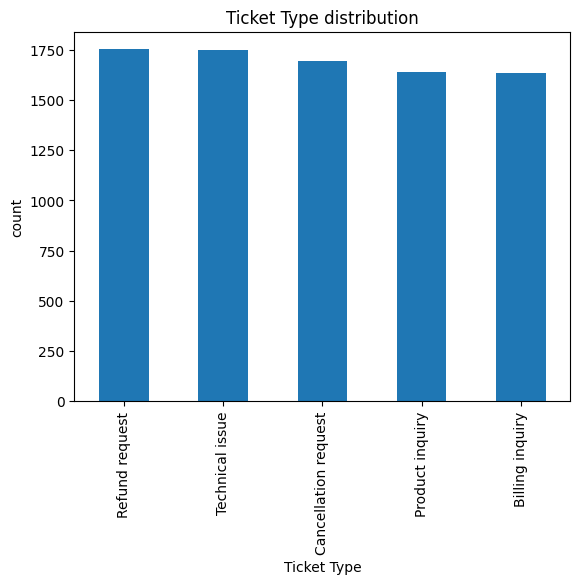

In [19]:
class_counts = data_ct["Ticket Type"].value_counts()
class_pct = data_ct["Ticket Type"].value_counts(normalize=True) * 100

print(class_counts)
print(class_pct.round(2))

class_counts.plot(kind="bar", title="Ticket Type distribution")
plt.ylabel("count")
plt.show()


count    8469.0
mean        2.0
std         0.0
min         2.0
25%         2.0
50%         2.0
75%         2.0
max         2.0
Name: desc_word_count, dtype: float64


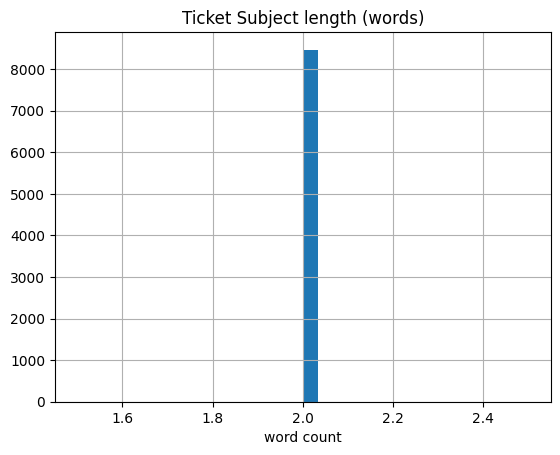

In [20]:
data_ct["desc_word_count"] = data_ct["Ticket Subject"].str.split().str.len()
print(data_ct["desc_word_count"].describe())

data_ct["desc_word_count"].hist(bins=30)
plt.title("Ticket Subject length (words)")
plt.xlabel("word count")
plt.show()

In [21]:
dupes = data_ct["Ticket Subject"].duplicated().sum()
print(f"Duplicate Subjects: {dupes}")

Duplicate Subjects: 8453


In [22]:
for cat in data_ct["Ticket Type"].unique():
    print(f"\n=== {cat} ===")
    print(data_ct[data_ct["Ticket Type"] == cat]["Ticket Subject"].sample(2, random_state=RANDOM_STATE).to_list())


=== Technical issue ===
['Product setup', 'Software bug']

=== Billing inquiry ===
['Network problem', 'Data loss']

=== Cancellation request ===
['Product compatibility', 'Battery life']

=== Product inquiry ===
['Software bug', 'Product compatibility']

=== Refund request ===
['Data loss', 'Product recommendation']


In [24]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    stopwords = {"the","is","and","a","an","to","of","in","on","for","with","that",
                 "this","it","as","at","by","from","be","are","was","were","has",
                 "had","have","he","his","she","hers","him","her"}
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    words = [w for w in text.split() if w not in stopwords]
    return " ".join(words)

data_ct["Preprocessed"] = data_ct["Ticket Subject"].apply(clean_text)
data_ct[["Ticket Subject", "Preprocessed"]].head()

,Ticket Subject,Preprocessed
0,Product setup,product setup
1,Peripheral compatibility,peripheral compatibility
2,Network problem,network problem
3,Account access,account access
4,Data loss,data loss


In [25]:
X = data_ct["Preprocessed"]
y = data_ct["Ticket Type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

print(X_train.shape, X_test.shape)

(5928,) (2541,)


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)   # transform only, never fit, on test data

In [27]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [28]:
from sklearn.metrics import classification_report, f1_score, accuracy_score

for name, model in [("Multinomial NB", nb), ("Logistic Regression", logreg)]:
    preds = model.predict(X_test_tfidf)
    print(f"\n=== {name} ===")
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Macro F1:", f1_score(y_test, preds, average="macro"))
    print(classification_report(y_test, preds))


=== Multinomial NB ===
Accuracy: 0.18693427784336875
Macro F1: 0.18491768233122374
                      precision    recall  f1-score   support

     Billing inquiry       0.18      0.12      0.15       490
Cancellation request       0.18      0.22      0.20       509
     Product inquiry       0.19      0.19      0.19       492
      Refund request       0.21      0.19      0.20       526
     Technical issue       0.17      0.21      0.19       524

            accuracy                           0.19      2541
           macro avg       0.19      0.19      0.18      2541
        weighted avg       0.19      0.19      0.19      2541


=== Logistic Regression ===
Accuracy: 0.18654073199527746
Macro F1: 0.18201847396943435
                      precision    recall  f1-score   support

     Billing inquiry       0.18      0.12      0.15       490
Cancellation request       0.18      0.22      0.20       509
     Product inquiry       0.18      0.13      0.15       492
      Refund requ